<a id=top></a>

# AM10 : Computing for Science and Engineering 

## Section 09

**Fall 2020**

<BR>

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
%matplotlib inline

## REVIEW: Functions for Euler and modified Euler methods

Below are presented the functions for the methods discussed in Lec and Lab for numerically solving the first-order ODE
$$ \frac{du}{dx} = f(x,u) $$

Note: $f(x,u)$ will be coded "separately" so that it can be changed (depending on the problem at hand) without modifying the core of the integration routines. 

### Function for the Euler method:

From Lecture 9, the propagating expression for the Euler's method is:
$$ 
u(x_{n+1}) = u(x_n) + \Delta x \cdot f(u(x_n), x_n)$$

In [2]:
def euler(Nx, xmin, xmax, uf0):
    #Diff eqn of form: d(uf)/dx=ff(x,uf) 
    #Nx: Number of points to be used for integration
    #xmin, xmax: Initial and final values of the independent variable (x)
    #uf0: Initial value of the dependent variable at x=xmin
    
    #Assume the function f(u,x) is of form:
    
    #ff(x[n], uf[n])
    
    #For any function f(u,x) on the RHS, you need to provide
    #a python function. For example, for the eigenfunction problem:
    
    #def ff(x, y):
    #    a=2.0
    #    dydx = a * y
    #    return dydx
    
    #Define x
    x = np.linspace(xmin, xmax, Nx)
    #Calculate dx
    dx = x[1] - x[0]
    #Set up the array for ux
    uf = np.zeros(Nx)
    #Define the initial condition
    uf[0] = uf0
    
    #We need to write another function ff(x[n],uf[n])
    #for the integrand. We will do it later when we need to
    #solve the equation for particular cases.
    for n in range(Nx - 1):
        #Fill in the code for uf[n+1]
        #--------------------------------------
        uf[n+1] = uf[n] + dx * ff(x[n], uf[n])
        #--------------------------------------
    return uf

### Function for the modified-Euler method
The formula for the modified-Euler method is:
$$u_{n+1} = u_n + \frac{1}{2} \Delta x \left \{ f(x_n, u_n) + f(x_{n+1}, u_n+\Delta x \cdot f(x_n, u_n) ) \right \}$$

In [3]:
def mod_euler(Nx, xmin, xmax, uf0):
    #Diff eqn of form: d(uf)/dx=ff(x,uf)
    #Nx: Number of points to be used for integration
    #xmin, xmax: Initial and final values of the independent variable (x)
    #uf0: Initial value of the dependent variable at x=xmin
     
    #Define x
    x = np.linspace(xmin, xmax, Nx)
    #Determine dx
    dx = x[1] - x[0]
    #Set up the array for ux and initialize it to zero
    uf = np.zeros(Nx)
    #Specify the boundary (initial) condition at x=xmin
    uf[0] = uf0

    for n in range(Nx - 1):
        # uf[n+1] is of the form: uf[n+1] = uf[n] + 0.5 * dx * (ff1 + ff2)
        #Write in the code for ff1 and ff2
        #--------------------------------------
        ff1 = ff(x[n], uf[n])
        ff2 = ff(x[n+1], uf[n] + dx * ff(x[n], uf[n]))
        #--------------------------------------------
        uf[n+1] = uf[n] + 0.5 * dx * (ff1 + ff2)
    return uf

## Problem 1

Solve the differential equation:

   \begin{equation}
    \frac{du}{dt} - u = t \ e^t
   \end{equation}

over the domain $0 \le t \le 5$, with the initial condition $u(0)=1.0$.

Try values of Nt = 50, 100, 200, 500. Use the functions you wrote for Euler and modified-Euler methods. Comment on the results. Plot the solutions.

This problem has the following function as the solution:
   \begin{equation}
    u(t)=e^t (t^2 / 2 + 1)
   \end{equation}
   

In [4]:
# your code here


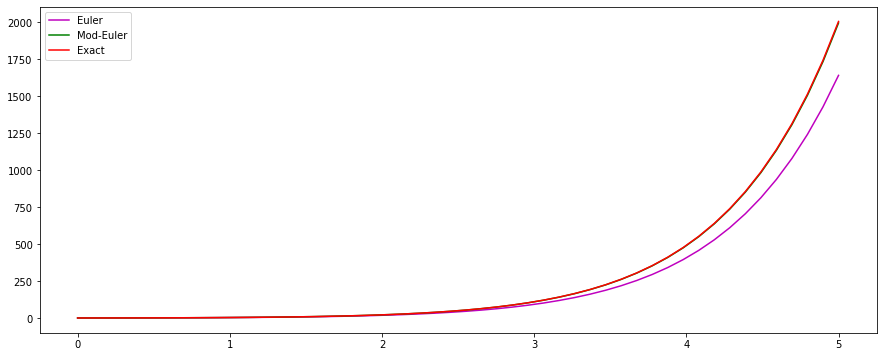

In [45]:
# Solution

Nt = 50

tmin = 0.
tmax = 5.

t = np.linspace(tmin, tmax, Nt)

# Initial condition 

uf00 = 1. #initial condition

#Function to be integrated
def ff(t,u):
    dudt = u + t*np.exp(t)
    return dudt

#Exact solution 
utrue10 = np.exp(t) * (t**2 / 2 + 1)

# Find the solution for initial condition uf00 and plot
uf10 = euler(Nt, tmin, tmax, uf00)
uf20 = mod_euler(Nt, tmin, tmax, uf00)

# Plot
plt.figure(figsize=(15,6))

plt.plot(t, uf10, 'm-',label="Euler")
plt.plot(t, uf20, 'g-',label="Mod-Euler")

plt.plot(t, utrue10, 'r-',label="Exact")

plt.legend(loc='upper left')
plt.show()

___________________________________________________________________________________________________________________________

## The SIR epidemic model
#### (SIR = Susceptible-Infective-Recovered)

A simple mathematical description of the spread of a disease in a population is the so-called SIR model, which divides the (fixed) population of N individuals into three groups (also called "compartments" or "classes"), namely S, I, R (defined below) which may vary as a function of the time, t:

- S(t) are those susceptible but not yet infected with the disease;
- I(t) is the number of infectious individuals;
- R(t) are those individuals who have recovered from the disease and now have permanent immunity to it.

The SIR model describes the change in the population of each of these groups (S, I, R) in terms of two parameters, $\beta$ and $\gamma$. $\beta$ describes the effective contact rate of the disease: an infected individual comes into contact with $\beta N$ other individuals per unit time (of which the fraction that are susceptible to contracting the disease is $\frac{S}{N}$). $\gamma$ is the mean recovery rate: that is, $\frac{1}{\gamma}$ is the mean period of time during which an infected individual can pass it on.

The differential equations describing this model were first derived by Kermack and McKendrick [Proc. R. Soc. A, 115, 772 (1927)]:

$$ \frac {dS}{dt} = - \frac{\beta S I}{N} $$

$$ \frac{dI}{dt} = \frac{\beta S I}{N} - \gamma I $$

$$ \frac{dR}{dt} = \gamma I $$

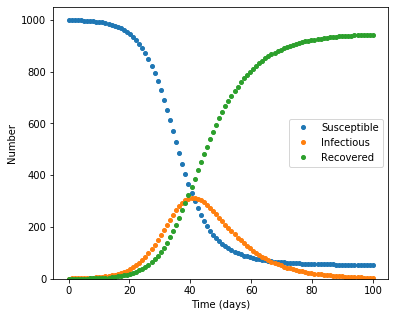

In [6]:
# Total population (N) and number of days (Ndays) of epidemic duration
N = 1000
Ndays=100

# Contact rate, beta, and mean recovery rate, gamma, (in 1/days).
beta = 0.3
gamma = 1.0/10

# Generating the time array:
t = np.linspace(0, Ndays, Ndays)
dt=t[1]-t[0]

# Initializing the S, I, R arrays
S=np.zeros(Ndays)
I=np.zeros(Ndays)
R=np.zeros(Ndays)

# start with one infected individual

S[0]=N
I[0]=1
R[0]=0

# Solving the system of differential equations
for n in range(Ndays-1):
    S[n+1]=S[n]+dt*(-beta*S[n]*I[n]/N)
    I[n+1]=I[n]+dt*(beta*S[n]*I[n]/N - gamma*I[n])
    R[n+1]=R[n]+dt*(gamma*I[n])
    
fig=plt.figure(figsize=(6,5))
plt.plot(t,S,'o',ms=4,label='Susceptible')
plt.plot(t,I,'o',ms=4,label='Infectious')
plt.plot(t,R,'o',ms=4,label='Recovered')
plt.xlabel('Time (days)')
plt.ylabel('Number')
plt.ylim(0,01.05*N)
plt.legend()
plt.show()

## Fitting SIR with sigmoids

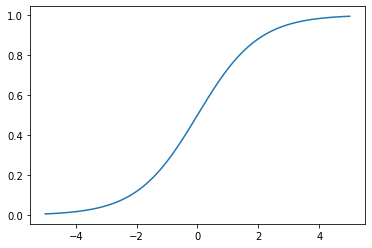

In [7]:
# The sigmoid function (a version of the theta-function)
xmin=-5
xmax=5
Nx=100
x=np.linspace(xmin,xmax,Nx)

sigx=1.0/(1.0+np.exp(-x))

plt.plot(x,sigx)

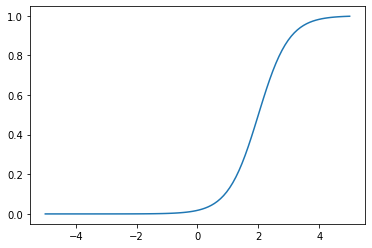

In [8]:
# The sigmoid function (parametrized by a, x0)
xmin=-5
xmax=5
Nx=100
x=np.linspace(xmin,xmax,Nx)

a=2.0
x0=2.0

sigx=1.0/(1.0+np.exp(-a*(x-x0)))

plt.plot(x,sigx)

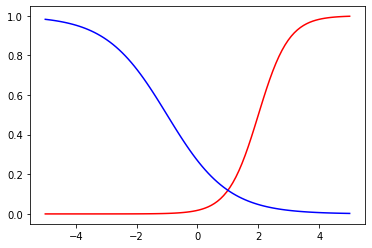

In [9]:
# Two sigmoid functions 
xmin=-5
xmax=5
Nx=100
x=np.linspace(xmin,xmax,Nx)

a1=2.0
a2=1.0
x01=2.0
x02=-1.0
sigx1=1.0/(1.0+np.exp(-a1*(x-x01)))
sigx2=1.0-1.0/(1.0+np.exp(-a2*(x-x02)))

plt.plot(x,sigx1, 'r-')
plt.plot(x,sigx2, 'b-')

In [10]:
def sigmoid(a,t0,t):
    return 1.0/(1.0+np.exp(-a*(t-t0)))

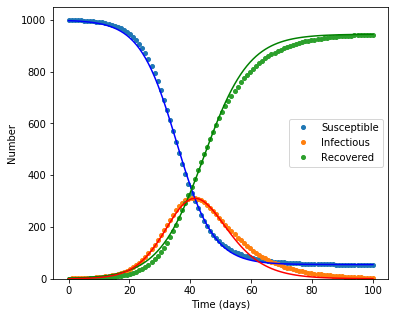

In [11]:
# Fit to model

# parameters for beta=0.3, gamma=1/10   
a1=0.165
a2=0.135
N2=N-55
t1=35.5        # midpoint of S
dt=9.0         # difference between midpoints of S and R
t2=t1+dt       # midpoint of R 

Smod=N-N2*sigmoid(a1,t1,t)
Rmod=N2*sigmoid(a2,t2,t)

fig=plt.figure(figsize=(6,5))
plt.plot(t,S,'o',ms=4,label='Susceptible')
plt.plot(t,I,'o',ms=4,label='Infectious')
plt.plot(t,R,'o',ms=4,label='Recovered')

Imod=N-Rmod-Smod

plt.plot(t,Smod,'b-')
plt.plot(t,Rmod,'g-')
plt.plot(t,Imod,'r-')
plt.xlabel('Time (days)')
plt.ylabel('Number')
plt.ylim(0,01.05*N)
plt.legend()
plt.show()

In [12]:
# Define here the model function for I(t) - difference of 2 sigmoids
def daily_fit(t,t1,dt,N2):
    a1=0.25
    a2=0.25
    t01=t1
    t02=t01+dt
    return N2*(sigmoid(a1,t01,t)-sigmoid(a2,t02,t))

___________________________________________________________________________________________________________________________

### Application: China (single Covid-19 wave)

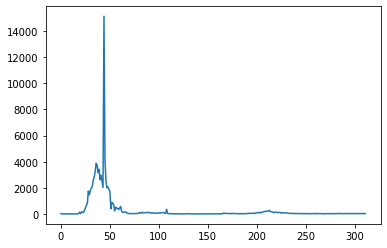

In [28]:
daily_CHN = np.loadtxt('China_Covid-19_cases.txt')
plt.plot(daily_CHN)
plt.show()

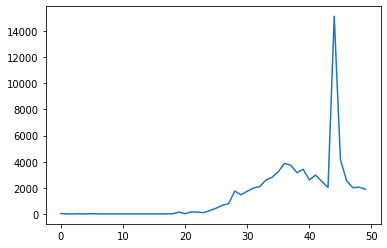

In [29]:
# Slice the data to get the first 50 days - plot the sliced data
#-----------------
fdat = daily_CHN[0:50]
#-----------------
plt.plot(fdat)
plt.show()

t1 = 34.47, Delta t = 14.16, N2 = 6121.18


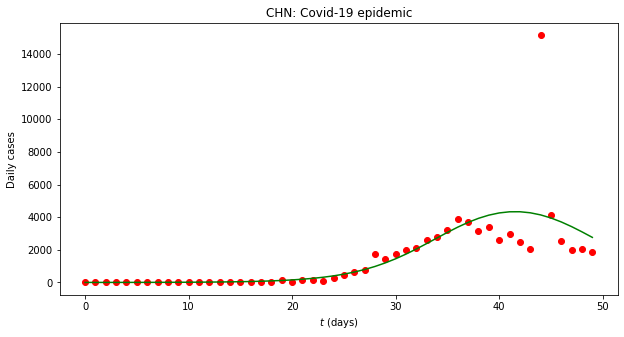

In [47]:
# fit the data

xdat = np.arange(len(fdat))

# -------------------------------------------
    
popt, pcov = curve_fit(daily_fit, xdat, fdat)
    
t1 = popt[0]
dt = popt[1]
N2 = popt[2]

print(f't1 = {popt[0]:.2f}, Delta t = {popt[1]:.2f}, N2 = {popt[2]:.2f}')

ffit = daily_fit(xdat, t1, dt, N2)    
#--------------------------------------------

fig=plt.figure(figsize=(10,5))
plt.plot(xdat,fdat,'ro')
plt.plot(xdat,ffit,'g')
plt.title('CHN: Covid-19 epidemic')
plt.ylabel('Daily cases')
plt.xlabel('$t$ (days)')
plt.show();
#fig.savefig('Daily_CHN.png',format='png')


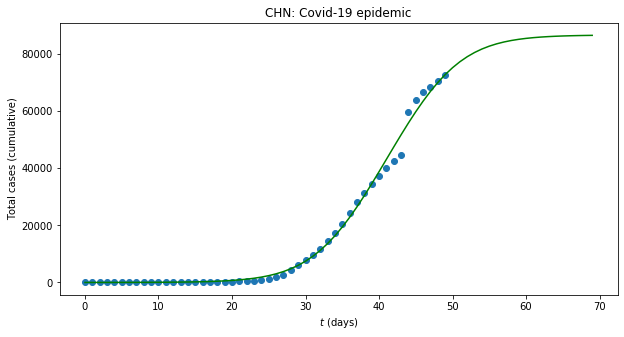

In [46]:
# CHN CUMULATIVE data and time-extension (PREDICTION)

cumm_dat=np.zeros(len(fdat))
cumm_dat[0]=fdat[0]
for i in range (1,len(fdat)):
    cumm_dat[i]=cumm_dat[i-1]+fdat[i]

T_ext=20     # extend T_ext = 20 days "in the future", that is, after the day of the last datapoint. 
xdat_ext = np.arange(len(fdat)+T_ext)
ffit_ext=daily_fit(xdat_ext, t1, dt, N2)
cumm_fit=np.zeros(len(fdat)+T_ext)
cumm_fit[0]=ffit[0]
for i in range (1,len(fdat)+T_ext):
    cumm_fit[i]=cumm_fit[i-1]+ffit_ext[i]
    
fig=plt.figure(figsize=(10,5))
plt.scatter(xdat,cumm_dat)
plt.plot(xdat_ext,cumm_fit,'g')
plt.title('CHN: Covid-19 epidemic')
plt.ylabel('Total cases (cumulative)')
plt.xlabel('$t$ (days)')
#plt.legend()
plt.show();

In [32]:
# Use the fit to predict Total Number of Cases and time of wave decay (to near zero cases)

Nt=cumm_fit[-1]
Ncut=0.99*Nt
for i in range (len(xdat_ext)):
    if cumm_fit[i] > Ncut:
        imax=i
        break
        
print(f'Ntotal = {int(cumm_fit[-1])},     Remaining days (till near zero cases) = {imax-len(xdat)}')

Ntotal = 86539,     Remaining days (till near zero cases) = 11


__________________________________________________________________________________________________________________________

## Problem 2

Calculate the RMSE of the fit in the previous example.
    

In [17]:
# your code here


In [33]:
# Solution

rmsfit=np.sqrt(np.sum((ffit-fdat)**2)/len(fdat))

print(f'RMSE = {rmsfit:.2f}')


RMSE = 1682.94


## Problem 3

#### Threshold for counting cases, `find_t0()`.

We want to get the arrays from the point in time when cases really started ramping up. This does not always coincide with the start of reporting. We will do this by checking when cases keep increasing for a consecutive `step` number of days. 

In other words, we find the onset of the exponential growth of the epidemic wave, by checking when cases keep increasing for a consecutive `step` number of days.

In [19]:
# your code here


In [34]:
# Solution

def find_t0(cumul, step):
    for i in range(len(cumul)-step):
        a=[cumul[j+i] < cumul[j+i+1] for j in range(step)]
        if np.all(a): return i+1
    return 0

In [35]:
find_t0(cumm_dat, 7)

17